# Data Vortex · Round 2 — Rebuilding the Semantic (NLP) Layer

**Team:** Forge-X · **Member:** Kunal Choudhary

**Theme:** Rebuilding the Social Engine · **Dataset:** Dataset 2 (labelled posts)
**Tasks:** sentiment classification (primary) + topic classification (secondary) + unsupervised topic-model agreement (bonus).

| Deliverable | Location |
|---|---|
| Model script / notebook | `src/round2/`, this notebook |
| Trained models | `models/round2/*.pkl` |
| Evaluation Metrics Report | `output/round2/Evaluation_Metrics_Report.pdf` |
| Round 2 Technical Report | `output/round2/Round2_Technical_Report.pdf` |

> **This notebook is the documented workflow, not a second implementation.**
> It calls the functions in `src/round2/` and reads `output/round2/metrics.json`
> -- the same file the PDFs render -- so notebook, models and reports share one
> source of truth.


## 1 · Data intake & split

Raw file is never modified; empties and exact duplicates go to named hold-outs; one shared stratified 80/20 split feeds both tasks.

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd() / "src" / "round2").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
from round2.data import load_splits
from round2 import config as C

train, test, profile, manifest = load_splits()
print("reconciliation:", profile["reconciliation"])
print(f"split: train {len(train):,} / test {len(test):,} "
      f"({manifest['stratify']}, seed {manifest['seed']})")
print("sentiment:", profile["sentiment_counts"])
print("topics   :", profile["topic_counts"])
print("conflicting-label texts kept as noise:", profile["n_conflicting_texts"])
train.head(3)

reconciliation: 9000 raw - 0 empty - 1100 exact-duplicate = 7900 modeled
split: train 6,320 / test 1,580 (sentiment_x_topic, seed 42)
sentiment: {'Negative': 2430, 'Neutral': 2748, 'Positive': 2722}
topics   : {'Account_Security': 129, 'Community_Discussion': 6803, 'Feature_Feedback': 250, 'Technical_Issues': 718}
conflicting-label texts kept as noise: 0


,text_id,post_text,sentiment_label,topic_category
0,TXT_01523,"Conor McGregor, Grade-A fighter &amp; Grade-A ...",Positive,Community_Discussion
1,TXT_04165,"@user also, thanks for adding the 9th season o...",Positive,Community_Discussion
2,TXT_08086,Samsung may offer 128GB variants of the Galaxy...,Positive,Community_Discussion


## 2 · Preprocessing demo (the shipped normaliser)

Same functions the fitted pipelines embed: export repair, masking, affect markers, negation scope.

In [2]:
from round2 import text_clean as tc

demos = ["some1 come wait in line with me Thursday at 3@target bc briana is being a bitch",
         "I do NOT love waiting... loooove this update!!! :) http://x.co/a @user #blessed",
         "Can't believe the app crashed again -- worst Friday ever :("]
for raw in demos:
    print("RAW :", raw)
    print("NORM:", tc.normalize_text(raw))
    print("TOKS:", tc.word_tokens(raw))
    print("ATTR:", tc.attributes_for_analysis(raw))
    print("-" * 80)

RAW : some1 come wait in line with me Thursday at 3@target bc briana is being a bitch
NORM: some1 come wait in line with me thursday at 3 <user> bc briana is being a bitch
TOKS: ['some1', 'come', 'wait', 'line', 'thursday', '3', '<user>', 'bc', 'briana', 'bitch']
ATTR: {'n_chars': 79, 'n_tokens': 10, 'has_url': False, 'has_mention': True, 'has_hashtag': False, 'has_emoji': False, 'has_negation': False, 'has_elong': False}
--------------------------------------------------------------------------------
RAW : I do NOT love waiting... loooove this update!!! :) http://x.co/a @user #blessed
NORM: i do not love waiting loove this update <smile> <url> <user> blessed <hashtag> <elong>
TOKS: ['not', 'NOT_love', 'NOT_waiting', 'NOT_loove', 'update', '<smile>', '<url>', '<user>', 'blessed', '<hashtag>', '<elong>']
ATTR: {'n_chars': 79, 'n_tokens': 11, 'has_url': True, 'has_mention': True, 'has_hashtag': True, 'has_emoji': True, 'has_negation': True, 'has_elong': True}
----------------------------

## 3 · Model selection (CV on train only)

Six-spec ladder, stratified 5-fold CV, macro-F1. Test set untouched.

In [3]:
import pandas as pd
metrics = json.loads((ROOT / "output" / "round2" / "metrics.json").read_text())
for task in ("sentiment", "topic"):
    rec = metrics["tasks"][task]
    rows = [{"model": n + ("  <-- winner" if n == rec["spec_name"] else ""),
             "cv_mean": round(s["cv_mean"], 4), "cv_std": round(s["cv_std"], 4),
             "best_params": s["best_params"]}
            for n, s in sorted(rec["specs"].items(), key=lambda kv: -kv[1]["cv_mean"])]
    print(f"--- {task} (margin over runner-up: {rec['cv_margin']:+.4f}; "
          f"calibrated: {rec['calibrated']}) ---")
    display(pd.DataFrame(rows))
    mcn = rec["mcnemar"]
    print(f"McNemar on test: b={mcn['b_a_right_b_wrong']}, c={mcn['c_a_wrong_b_right']}, "
          f"p={mcn['p_value']:.4f} (significant: {mcn['significant_05']})\n")

--- sentiment (margin over runner-up: +0.0081; calibrated: False) ---


,model,cv_mean,cv_std,best_params
0,logreg_union <-- winner,0.6110,0.0148,"{'clf__C': 0.5, 'clf__class_weight': 'balanced'}"
1,svc_union,0.6028,0.0091,"{'clf__C': 0.25, 'clf__class_weight': None}"
2,logreg_word,0.5915,0.0156,"{'clf__C': 1.0, 'clf__class_weight': 'balanced'}"
3,svc_word,0.5893,0.0136,"{'clf__C': 0.25, 'clf__class_weight': 'balanced'}"
4,nb_word,0.5709,0.0120,{'clf__alpha': 0.5}
5,dummy,0.3240,0.0067,{}


McNemar on test: b=68, c=51, p=0.1421 (significant: False)

--- topic (margin over runner-up: +0.0134; calibrated: True) ---


,model,cv_mean,cv_std,best_params
0,svc_union <-- winner,0.7800,0.0374,"{'clf__C': 2.0, 'clf__class_weight': 'balanced'}"
1,logreg_union,0.7666,0.0339,"{'clf__C': 1.0, 'clf__class_weight': 'balanced'}"
2,svc_word,0.6042,0.0361,"{'clf__C': 2.0, 'clf__class_weight': 'balanced'}"
3,logreg_word,0.5791,0.0278,"{'clf__C': 4.0, 'clf__class_weight': 'balanced'}"
4,nb_word,0.3768,0.0452,{'clf__alpha': 0.1}
5,dummy,0.2397,0.0112,{}


McNemar on test: b=23, c=1, p=0.0000 (significant: True)



## 4 · Held-out test results

In [4]:
for task in ("sentiment", "topic"):
    t = metrics["tasks"][task]["test_recomputed"]
    print(f"--- {task} ({metrics['tasks'][task]['spec_name']}, n={t['n']:,}) ---")
    for k in ("accuracy", "f1_macro", "f1_weighted", "mcc", "roc_auc_ovr",
              "log_loss", "brier_ovr_mean"):
        print(f"  {k:14s} {t[k]}")
    display(pd.DataFrame(metrics["tasks"][task]["test_recomputed"]["per_class"]).T)
    print()

--- sentiment (logreg_union, n=1,580) ---
  accuracy       0.6132911392405064
  f1_macro       0.6133863327476102
  f1_weighted    0.6117360216276309
  mcc            0.4201466518263181
  roc_auc_ovr    0.7915894837175336
  log_loss       0.8620621593529527
  brier_ovr_mean 0.17025561599593106


,precision,recall,f1,support
Negative,0.633721,0.672840,0.652695,486.0
Neutral,0.565476,0.519126,0.541311,549.0
Positive,0.637500,0.655046,0.646154,545.0



--- topic (svc_union, n=1,580) ---
  accuracy       0.9677215189873418
  f1_macro       0.8051420716223598
  f1_weighted    0.9630920279900589
  mcc            0.8644550807392148
  roc_auc_ovr    0.978892766834865
  log_loss       0.11627838033023989
  brier_ovr_mean 0.01400372879566809


,precision,recall,f1,support
Account_Security,1.000000,0.500000,0.666667,26.0
Community_Discussion,0.965199,0.999265,0.981936,1360.0
Feature_Feedback,1.000000,0.440000,0.611111,50.0
Technical_Issues,0.985401,0.937500,0.960854,144.0


### Confusion matrices, ROC, CV detail, learning curves

### r2_03_confusion_sent.png


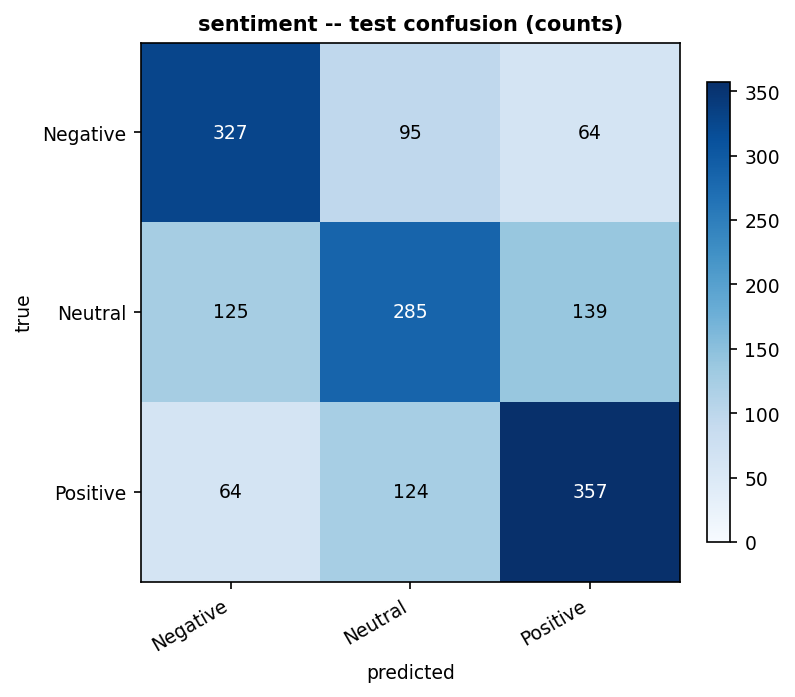

### r2_04_confusion_sent_norm.png


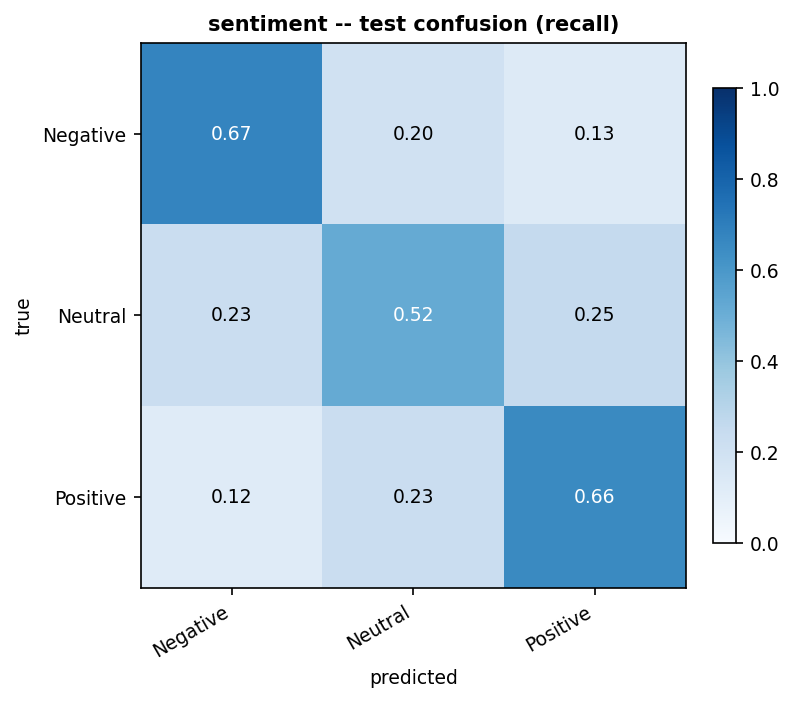

### r2_03_confusion_top.png


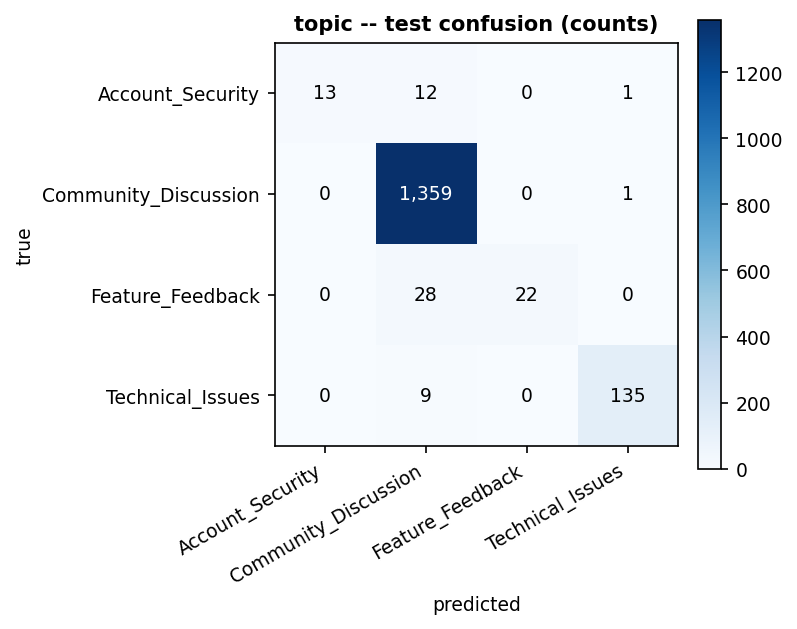

### r2_04_confusion_top_norm.png


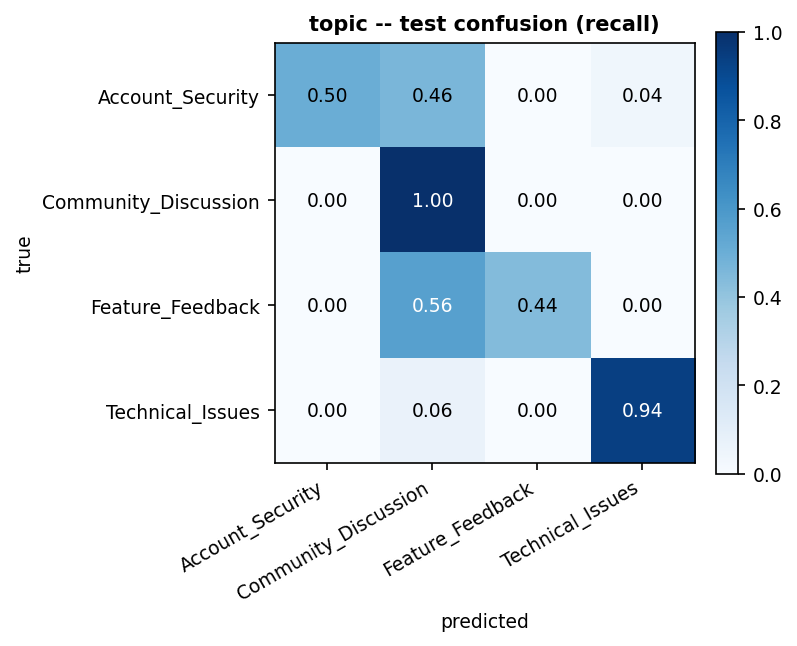

### r2_06_roc_sent.png


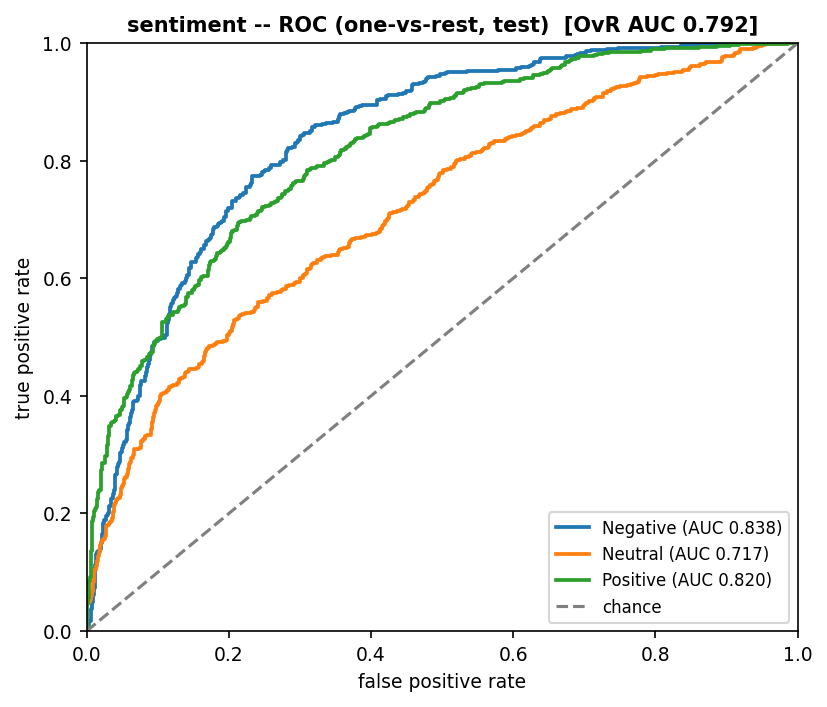

### r2_06_roc_top.png


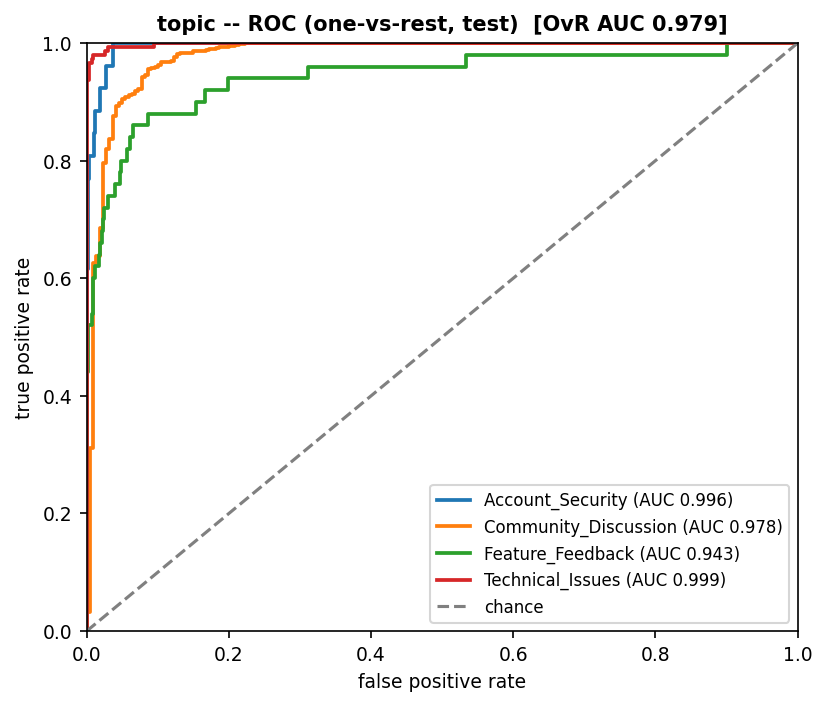

### r2_08_learn_sent.png


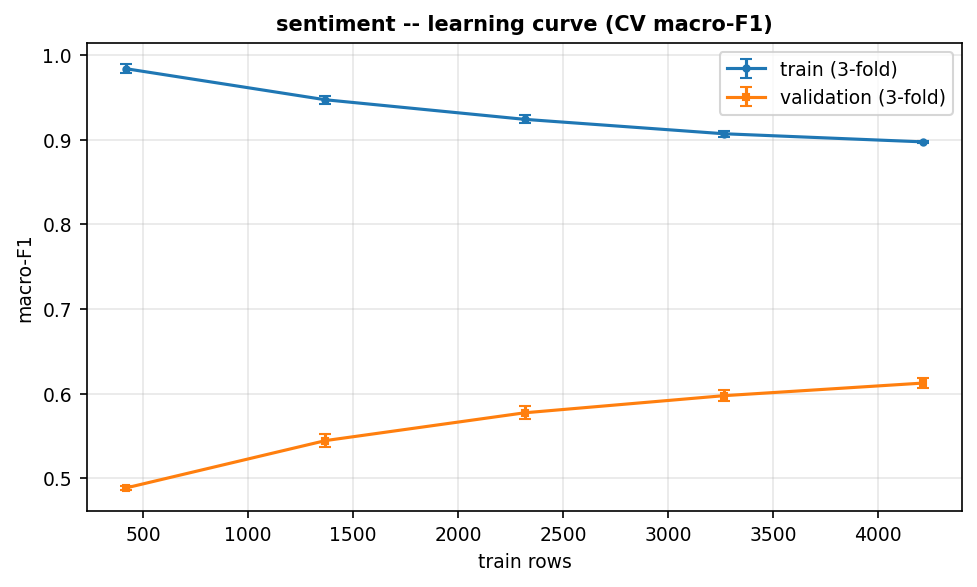

### r2_08_learn_top.png


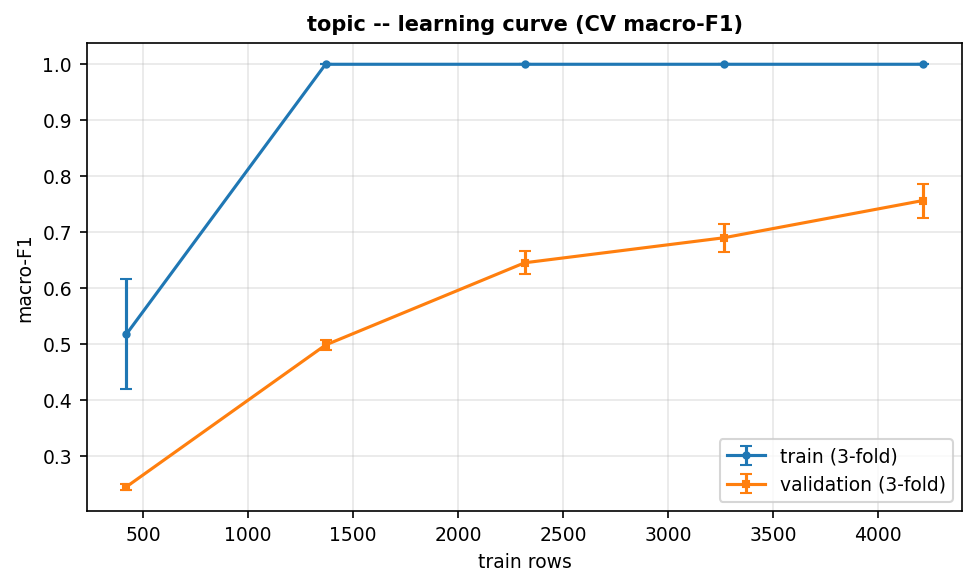

### r2_07_reliability_sent.png


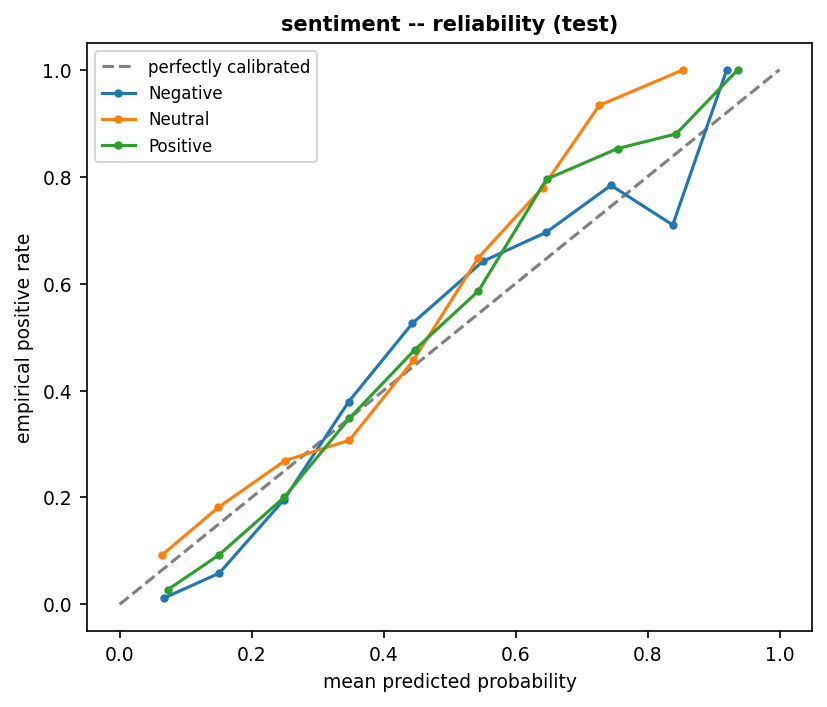

### r2_07_reliability_top.png


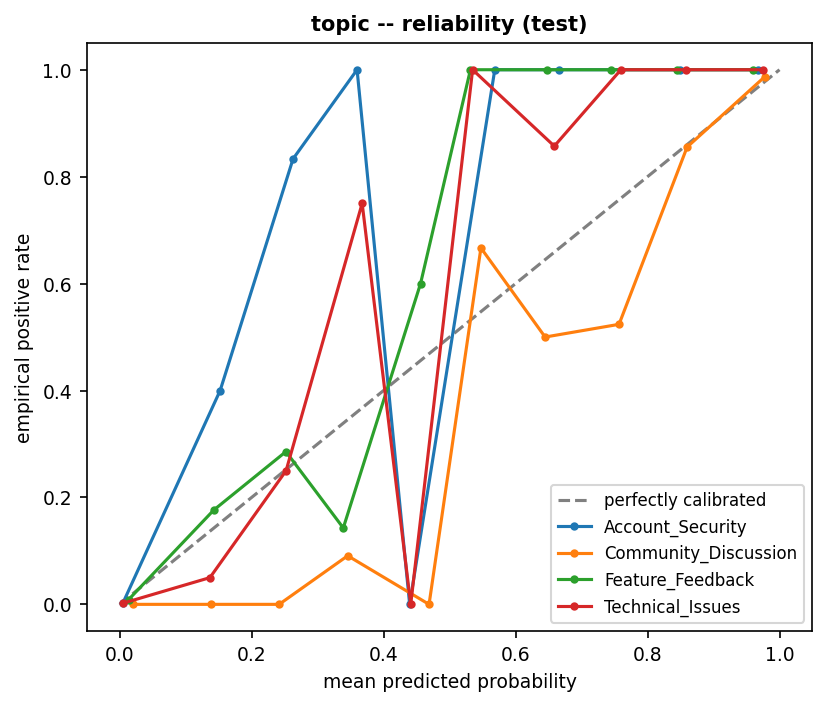

### r2_09_slices_sent.png


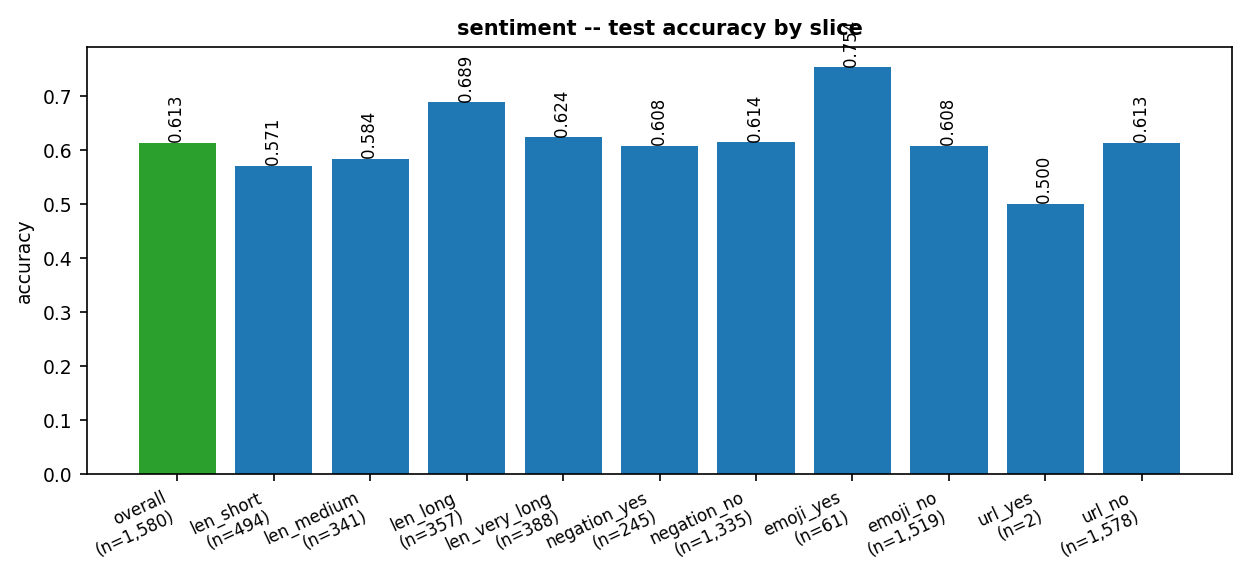

### r2_09_slices_top.png


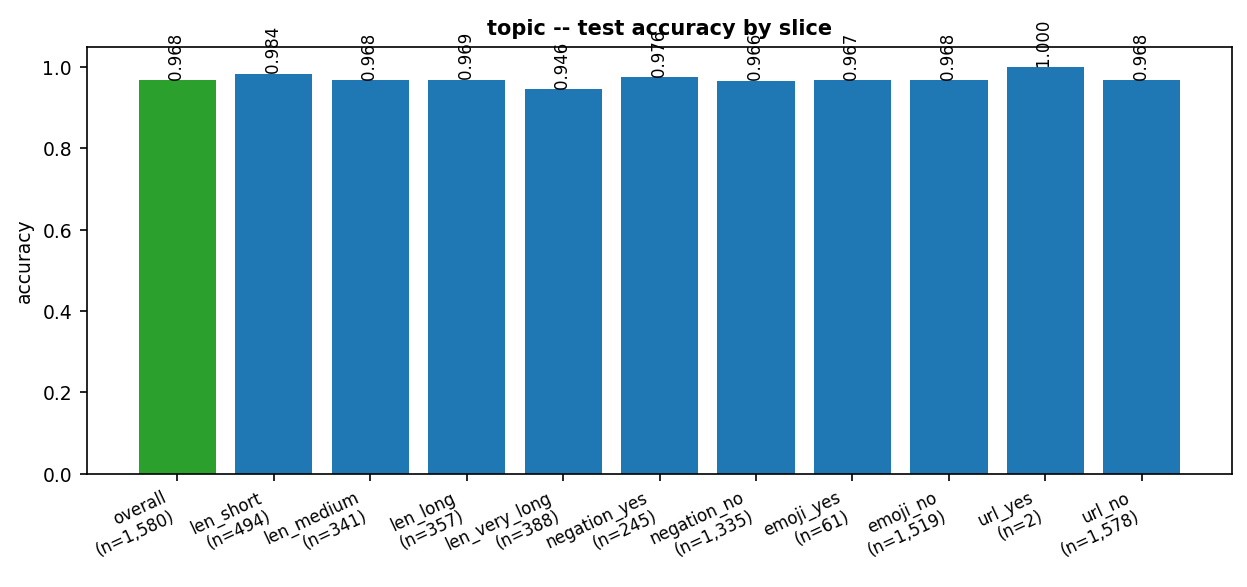

In [5]:
from IPython.display import Image, display
for fig in ["r2_03_confusion_sent.png", "r2_04_confusion_sent_norm.png",
            "r2_03_confusion_top.png", "r2_04_confusion_top_norm.png",
            "r2_06_roc_sent.png", "r2_06_roc_top.png",
            "r2_08_learn_sent.png", "r2_08_learn_top.png",
            "r2_07_reliability_sent.png", "r2_07_reliability_top.png",
            "r2_09_slices_sent.png", "r2_09_slices_top.png"]:
    p = ROOT / "output" / "round2" / "figures" / fig
    if p.exists():
        print(f"### {fig}")
        display(Image(str(p), width=640))

## 5 · Error analysis: real mistakes + measured slices

In [6]:
errs = metrics["tasks"]["sentiment"]["errors"]
print(f"{len(errs)} sampled sentiment errors (up to 3 per confusion cell):")
display(pd.DataFrame(errs).head(10))
print("\nSlice accuracy (sentiment test):")
display(pd.DataFrame(metrics["tasks"]["sentiment"]["slices"]).T)

18 sampled sentiment errors (up to 3 per confusion cell):


,text_id,true,pred,text
0,TXT_00108,Negative,Neutral,November 21 in the lonely hour tour.. OKAY SAM...
1,TXT_00170,Negative,Neutral,@user u 2 missed it. statement was plotted to ...
2,TXT_00209,Negative,Neutral,"@user zayn left on the 25th, school starts on ..."
3,TXT_00037,Negative,Positive,I'm going to the Duke game on Saturday. Haha. ...
4,TXT_00087,Negative,Positive,I think I may be the only person around not ex...
5,TXT_00262,Negative,Positive,Currently downloading the Saturday night fever...
6,TXT_00276,Neutral,Negative,"""If you wonder why we keep on this sustainable..."
7,TXT_00319,Neutral,Negative,I never expect too much. Expect too much and y...
8,TXT_00443,Neutral,Negative,@user friend I heard that Rahul Gandhi is inte...
9,TXT_00082,Neutral,Positive,now watching Denzel Washington talking about h...



Slice accuracy (sentiment test):


,n,accuracy,f1_macro
overall,1580.0,0.6133,0.6134
len_short,494.0,0.5709,0.5697
len_medium,341.0,0.5836,0.5852
len_long,357.0,0.6891,0.6791
len_very_long,388.0,0.6237,0.6233
negation_yes,245.0,0.6082,0.5325
negation_no,1335.0,0.6142,0.6152
emoji_yes,61.0,0.7541,0.5930
emoji_no,1519.0,0.6076,0.6086
url_yes,2.0,0.5000,0.2222


## 6 · Bonus: unsupervised topics vs human labels

K = 4 (one per human topic); agreement scored on TEST argmax-topics
LDA: NMI 0.0020 | ARI -0.0030 | homogeneity 0.0035 | completeness 0.0014
NMF: NMI 0.0027 | ARI 0.0068 | homogeneity 0.0046 | completeness 0.0019


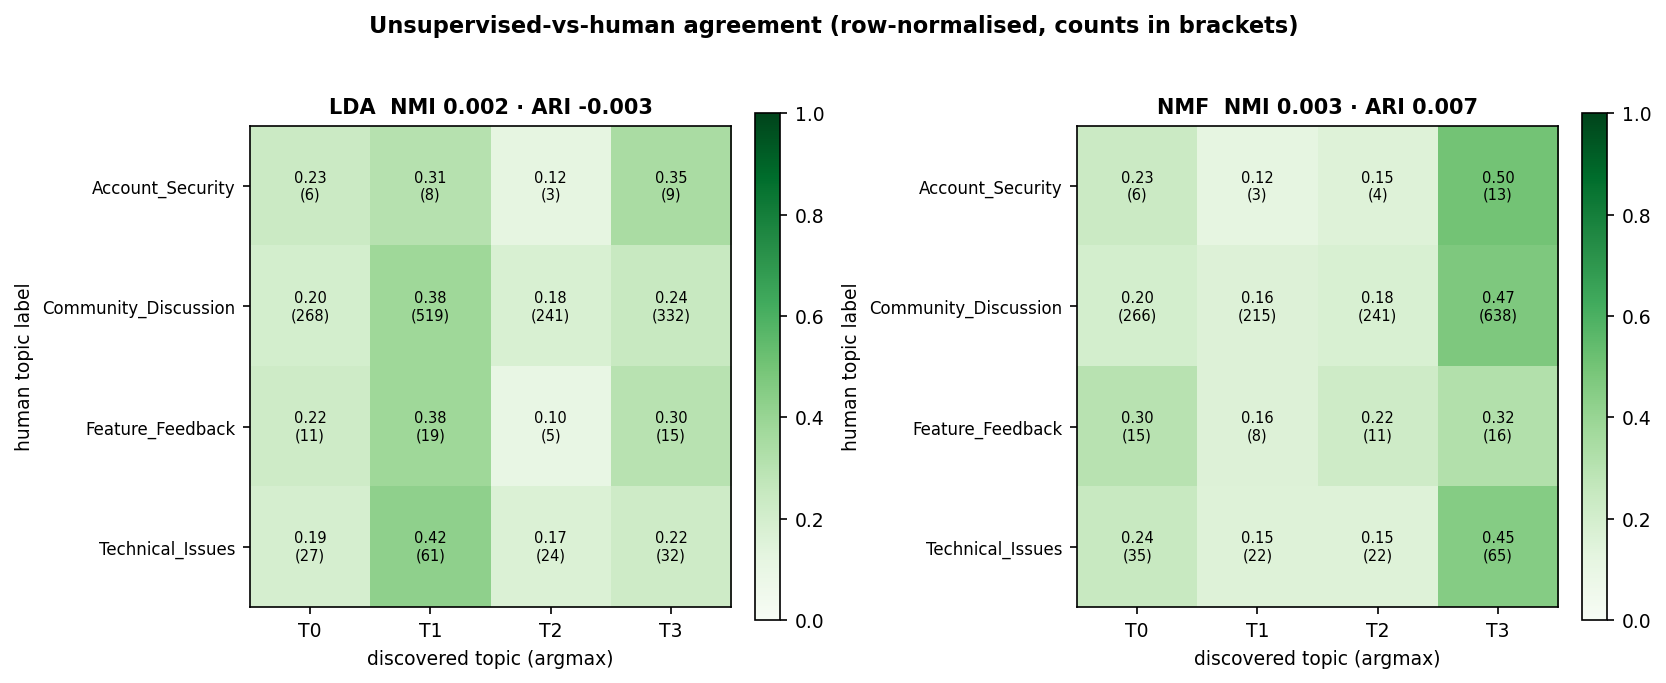

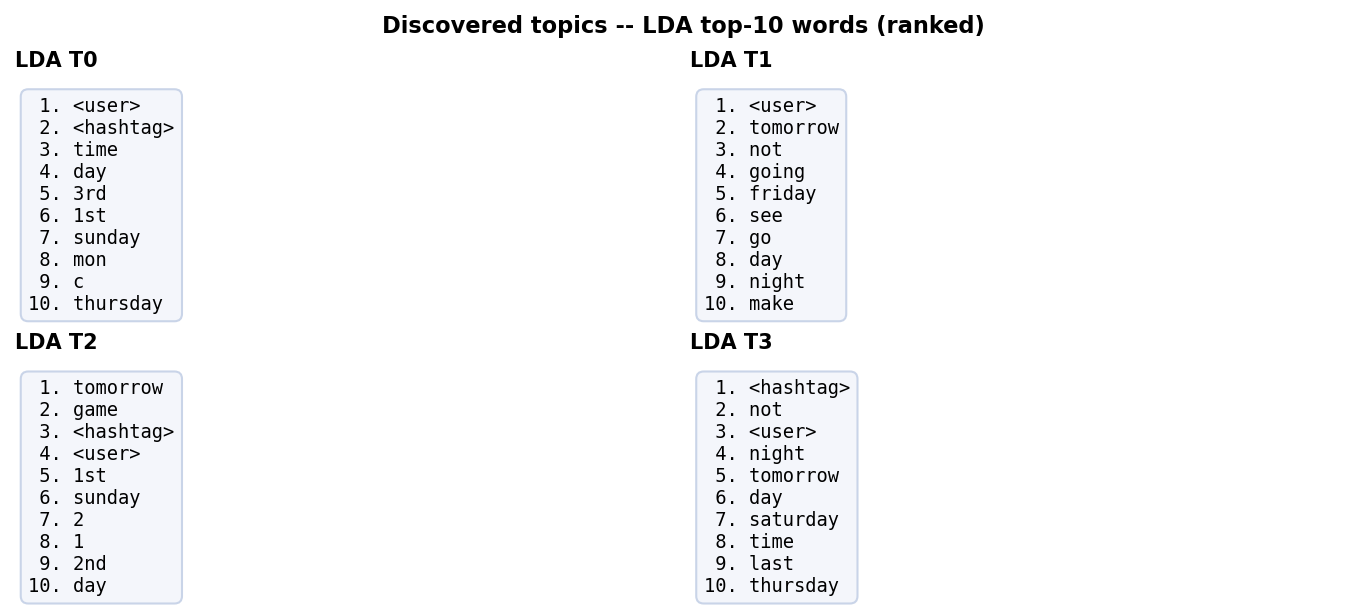

In [7]:
uns = metrics["unsupervised"]
print(f"K = {uns['K']} (one per human topic); agreement scored on TEST argmax-topics")
for algo in ("lda", "nmf"):
    a = uns[algo]["agreement"]
    print(f"{algo.upper()}: NMI {a['nmi']:.4f} | ARI {a['ari']:.4f} | "
          f"homogeneity {a['homogeneity']:.4f} | completeness {a['completeness']:.4f}")
display(Image(str(ROOT / "output/round2/figures/r2_11_agreement.png"), width=760))
display(Image(str(ROOT / "output/round2/figures/r2_10_lda_words.png"), width=760))

## 7 · Live inference with the shipped bundles

In [8]:
import joblib
bundles = {t: joblib.load(ROOT / "models" / "round2" / f"{t}_best.pkl")
           for t in ("sentiment", "topic")}
posts = ["I absolutely love the new update, best Friday ever!!",
         "This app keeps crashing and support never replies. Furious.",
         "Reminder: community meetup moved to Sunday, see you there."]
for post in posts:
    print("POST:", post)
    for task, b in bundles.items():
        pred = b["pipeline"].predict([post])[0]
        if hasattr(b["pipeline"], "predict_proba"):
            proba = b["pipeline"].predict_proba([post])[0]
            terms = ", ".join(f"{c}={p:.2f}"
                              for c, p in zip(b["pipeline"].classes_, proba))
            print(f"  {task:10s} -> {pred}   ({terms})")
        else:
            print(f"  {task:10s} -> {pred}")
    print()

POST: I absolutely love the new update, best Friday ever!!
  sentiment  -> Positive   (Negative=0.01, Neutral=0.02, Positive=0.96)
  topic      -> Technical_Issues   (Account_Security=0.00, Community_Discussion=0.00, Feature_Feedback=0.00, Technical_Issues=0.99)

POST: This app keeps crashing and support never replies. Furious.
  sentiment  -> Negative   (Negative=0.60, Neutral=0.24, Positive=0.16)
  topic      -> Technical_Issues   (Account_Security=0.00, Community_Discussion=0.00, Feature_Feedback=0.00, Technical_Issues=1.00)

POST: Reminder: community meetup moved to Sunday, see you there.
  sentiment  -> Positive   (Negative=0.16, Neutral=0.40, Positive=0.45)
  topic      -> Community_Discussion   (Account_Security=0.00, Community_Discussion=0.99, Feature_Feedback=0.01, Technical_Issues=0.00)



## 8 · Reproduce everything

```bash
pip install -r requirements-round2.txt
./run_round2.sh   # intake -> train -> evaluate -> PDFs -> notebook
```

| Artefact | Path |
|---|---|
| Metrics (renders both PDFs) | `output/round2/metrics.json` |
| Figures | `output/round2/figures/r2_*.png` |
| Models | `models/round2/*.pkl` |
| Upload set | `submission/round2/` + `MANIFEST.md` |
